In [1]:
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms
import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

import time

!pip install networkx
import networkx as nx

In [2]:
lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.data import *

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [3]:
dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [4]:
community_dict_stim = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/StimOn/community_stimOn_dict.pt', weights_only=False)
Mat_dict_stim = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/Confusion_mat_stimOn_times.pt', weights_only=False)

In [5]:
community_dict_rest = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/community_dict.pt', weights_only=False)
Mat_dict_rest = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/Confusion_mat.pt', weights_only=False)

In [24]:
Mat_dict_stim_repeat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/repeat/Confusion_mat_stimOn_times_repeat.pt', weights_only=False)
Mat_dict_rest_repeat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/repeat/Confusion_mat_stimOff_times_repeat.pt', weights_only=False)

Mat_dict_stim_1024_repeat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Nature/results/communities/Confusion_mat_stimOn_times_1024_repeat.pt', weights_only=False)
Mat_dict_rest_1024_repeat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Nature/results/communities/Confusion_mat_stimOff_times_1024_repeat.pt', weights_only=False)

In [25]:
import copy

def modularity_separation(M, resolution, sort=True):
    G = nx.from_numpy_array(M)
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    acronym_label = []
    community_label = []
    index = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            acronym_label.append(acronym_list[c_index])
            index.append(c_index)

    community_label = np.array(community_label)
    acronym_label = np.array(acronym_label)
    index = np.array(index)

    if sort == True:
        sort_index = np.argsort(index)
        community_label = community_label[sort_index]
        acronym_label = acronym_label[sort_index]
        index = index[sort_index]

    return community_label, acronym_label, index

In [26]:
community_dict = {}
rep = 0
key = 'stimOff'
Mat_dict = Mat_dict_rest_1024_repeat[rep]
for resolution in [0.4, 0.6, 0.8, 1.0, 1.2]:

    community_number = []
    community_index = {}
    community_dat = {}
    for name in ['AnyNet', 'ViT', 'RNN']:
        X = copy.deepcopy(Mat_dict[name])
        community_label, acronym_label, index = modularity_separation(X, resolution)
        community_number.append(len(np.unique(community_label)))
        community_index[name] = community_label

    communities = []
    communities_label = []
    communities_acronym = []
    ii = 0
    for community_ii_AnyNet in range(0, community_number[0]):
        for community_ii_ViT in range(0, community_number[1]):
            for community_ii_RNN in range(0, community_number[2]):
                community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                if len(community0) > 2:
                    communities.append(community0)
                    communities_acronym.append(np.array(acronym_list)[community0])
                    communities_label.append(ii * np.ones_like(community0))
                    ii = ii + 1

    communities = np.concat(communities)
    communities_label = np.concat(communities_label)
    communities_acronym = np.concat(communities_acronym)
    community_dat['communities'] = communities
    community_dat['communities_label'] = communities_label
    community_dat['communities_acronym'] = communities_acronym

    community_dict[resolution] = community_dat

In [27]:
torch.save(community_dict, f'/content/drive/MyDrive/Project/BrainRegionId/Nature/results/communities/community_dict_1024_{key}.pt')

In [28]:
community_dict = {}
rep = 0
key = 'stimOn'
Mat_dict = Mat_dict_stim_1024_repeat[rep]
for resolution in [0.4, 0.6, 0.8, 1.0, 1.2]:

    community_number = []
    community_index = {}
    community_dat = {}
    for name in ['AnyNet', 'ViT', 'RNN']:
        X = copy.deepcopy(Mat_dict[name])
        community_label, acronym_label, index = modularity_separation(X, resolution)
        community_number.append(len(np.unique(community_label)))
        community_index[name] = community_label

    communities = []
    communities_label = []
    communities_acronym = []
    ii = 0
    for community_ii_AnyNet in range(0, community_number[0]):
        for community_ii_ViT in range(0, community_number[1]):
            for community_ii_RNN in range(0, community_number[2]):
                community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                if len(community0) > 2:
                    communities.append(community0)
                    communities_acronym.append(np.array(acronym_list)[community0])
                    communities_label.append(ii * np.ones_like(community0))
                    ii = ii + 1

    communities = np.concat(communities)
    communities_label = np.concat(communities_label)
    communities_acronym = np.concat(communities_acronym)
    community_dat['communities'] = communities
    community_dat['communities_label'] = communities_label
    community_dat['communities_acronym'] = communities_acronym

    community_dict[resolution] = community_dat


torch.save(community_dict, f'/content/drive/MyDrive/Project/BrainRegionId/Nature/results/communities/community_dict_1024_{key}.pt')

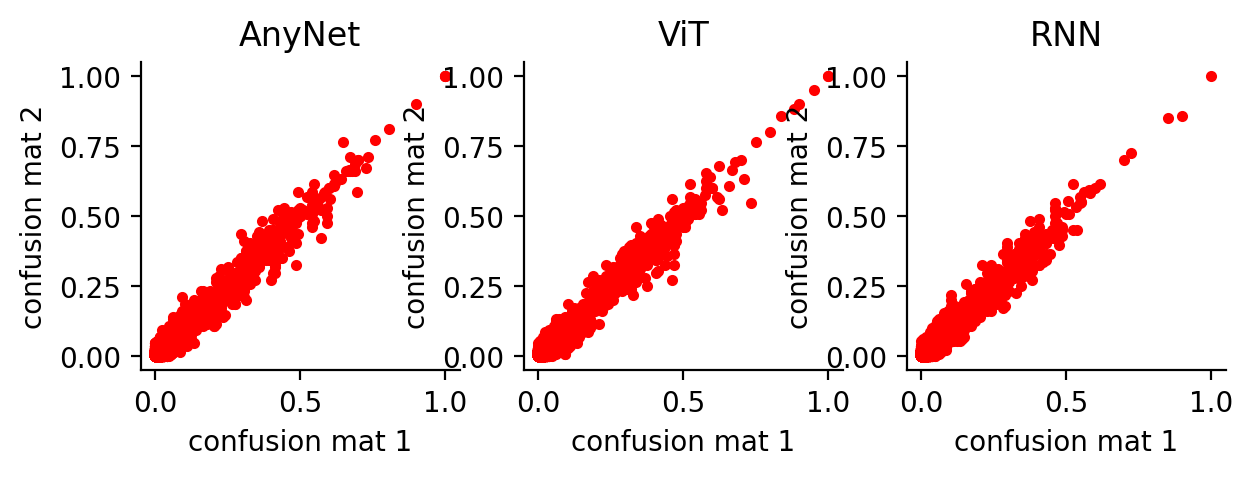

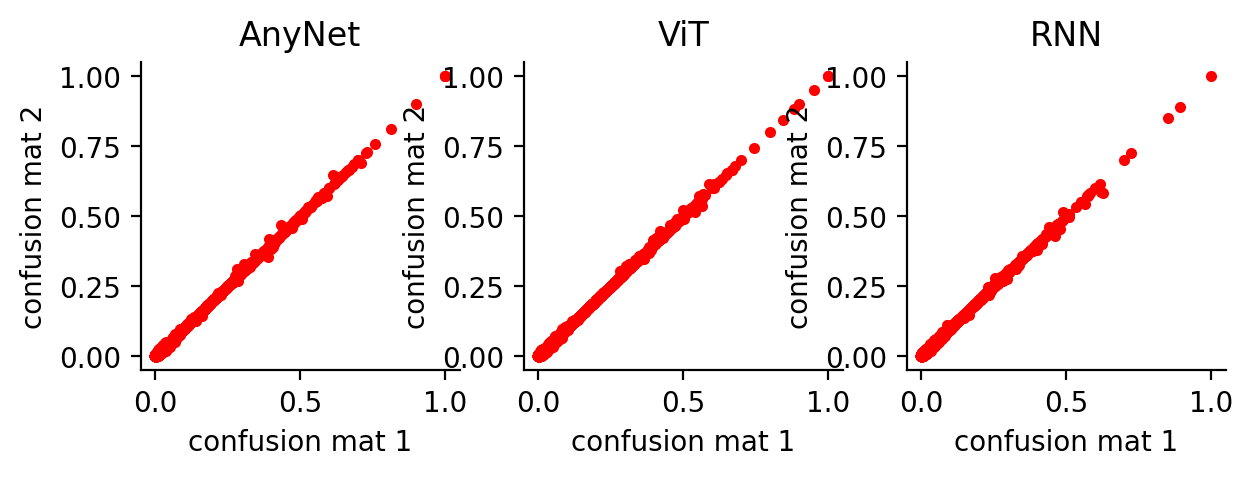

In [7]:
plt.figure(figsize=(7, 2), dpi=200)
for ii, classifier_name in enumerate(['AnyNet', 'ViT', 'RNN']):
    plt.subplot(1, 3, ii + 1)
    plt.plot(Mat_dict_rest_repeat[0][classifier_name], Mat_dict_rest[classifier_name], 'r.')
    plt.title(classifier_name)
    plt.xlabel('confusion mat 1')
    plt.ylabel('confusion mat 2')


sns.despine()
plt.show()

plt.figure(figsize=(7, 2), dpi=200)
for ii, classifier_name in enumerate(['AnyNet', 'ViT', 'RNN']):
    plt.subplot(1, 3, ii + 1)
    plt.plot(Mat_dict_rest_1024_repeat[0][classifier_name], Mat_dict_rest_1024_repeat[1][classifier_name], 'r.')
    plt.title(classifier_name)
    plt.xlabel('confusion mat 1')
    plt.ylabel('confusion mat 2')


sns.despine()
plt.show()

In [8]:
ratio_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Nature/results/communities/ratio_dict_stimOff_times.pt', weights_only=False)

[0]
FL
[1]
PC5
[31]
SSp-bfd5
[23]
SCdg
[28]
VISC5
[17]
MPO
[19]
MRN
[6]
CP
[2]
VISp5
[14]
DG-mo
[11]
CA1
[11]
FRP2/3
[29]
AUDd5
[19]
TRN
[30]
PF
[32]
SSp-tr5
[33]
SSp-un5
[15]
VISa5
[37]
PL2/3
[40]
XII
[41]
VISam5


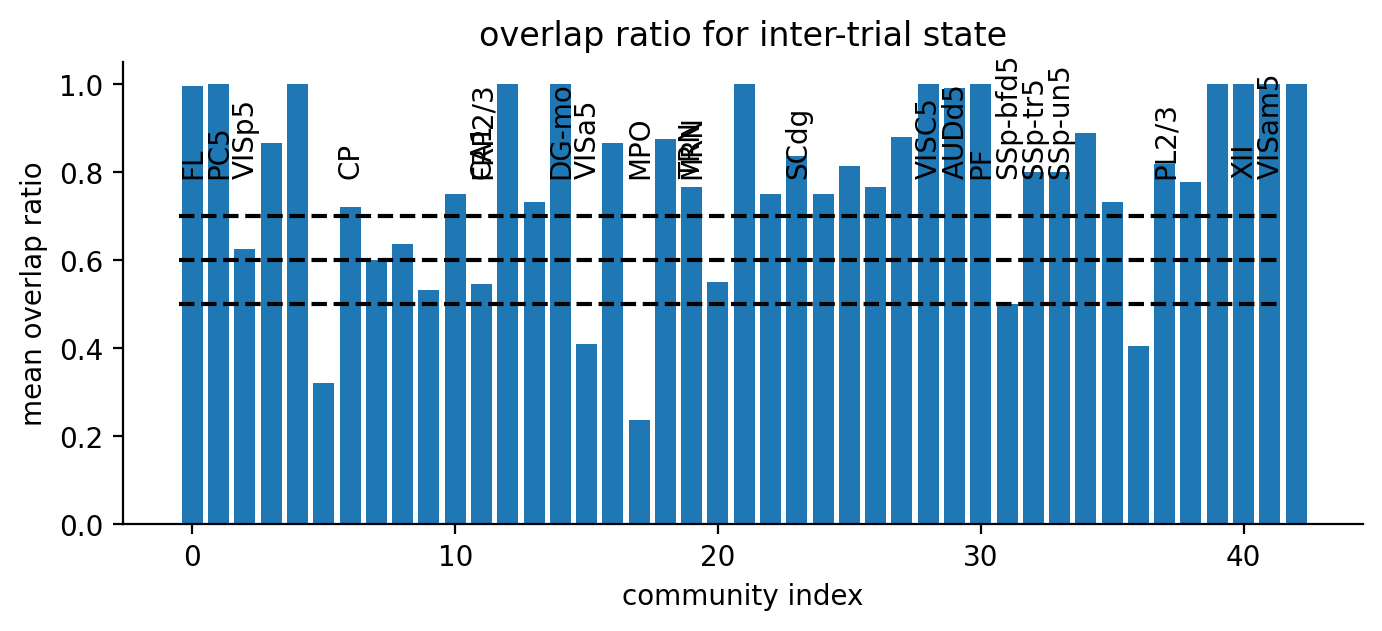

In [22]:
plt.figure(figsize=(8, 3), dpi=200)
plt.bar(ratio_dict['label_id'], ratio_dict['ratio'])
plt.plot([-0.5, 41.5], [0.6, 0.6], 'k--')
plt.plot([-0.5, 41.5], [0.7, 0.7], 'k--')
plt.plot([-0.5, 41.5], [0.5, 0.5], 'k--')
plt.xlabel('community index')
plt.ylabel('mean overlap ratio')
plt.title('overlap ratio for inter-trial state')
# plt.xlim([-0.5, 31.5])
for acronym_mark in ['FL', 'PC5', 'SSp-bfd5',
                     'SCdg', 'VISC5', 'MPO', 'MRN',
                     'CP', 'VISp5', 'DG-mo', 'CA1', 'FRP2/3', 'AUDd5', 'TRN', 'PF', 'SSp-tr5', 'SSp-un5', 'VISa5', 'PL2/3', 'XII', 'VISam5']:
    try:
        pos = community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym_mark).flatten()]
        print(pos)
        plt.text(pos-0.5, 0.8, acronym_mark, rotation=90)
        print(acronym_mark)
    except:
        continue
sns.despine()
plt.show()

In [23]:
ratio_dict['ratio'].mean()

np.float64(0.7804449673926419)

In [14]:
import copy

def modularity_separation(M, resolution, sort=True):
    G = nx.from_numpy_array(M)
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    acronym_label = []
    community_label = []
    index = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            acronym_label.append(acronym_list[c_index])
            index.append(c_index)

    community_label = np.array(community_label)
    acronym_label = np.array(acronym_label)
    index = np.array(index)

    if sort == True:
        sort_index = np.argsort(index)
        community_label = community_label[sort_index]
        acronym_label = acronym_label[sort_index]
        index = index[sort_index]

    return community_label, acronym_label, index

In [ ]:
ba_selec = ['MRN', 'VISp5', 'CP', 'VISam']

In [ ]:
ratio_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/repeat/ratio_dict_stimOff_times.pt', weights_only=False)

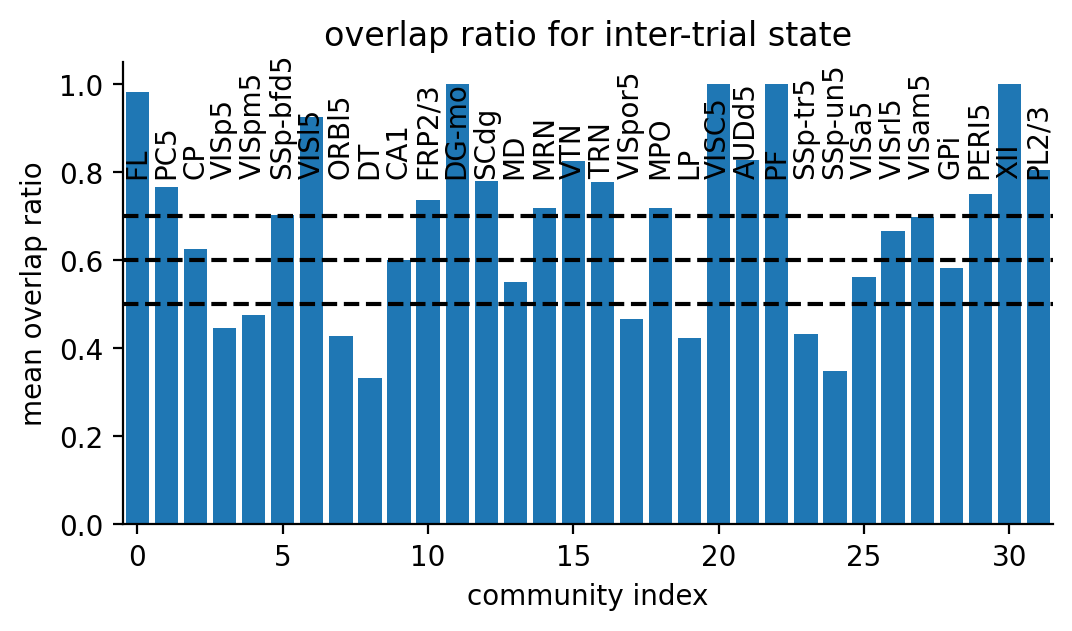

In [ ]:
plt.figure(figsize=(6, 3), dpi=200)
plt.bar(ratio_dict['label_id'], ratio_dict['ratio'])
plt.plot([-0.5, 31.5], [0.6, 0.6], 'k--')
plt.plot([-0.5, 31.5], [0.7, 0.7], 'k--')
plt.plot([-0.5, 31.5], [0.5, 0.5], 'k--')
plt.xlabel('community index')
plt.ylabel('mean overlap ratio')
plt.title('overlap ratio for inter-trial state')
plt.xlim([-0.5, 31.5])
for acronym_mark in ['FL', 'PC5', 'VISpm5', 'SSp-bfd5', 'VISl5', 'ORBl5', 'DT',
                     'SCdg', 'MD', 'VTN', 'VISpor5', 'VISC5', 'MPO', 'MRN', 'LP',
                     'CP', 'VISp5', 'DG-mo', 'CA1', 'FRP2/3', 'AUDd5', 'TRN', 'PF', 'SSp-tr5', 'SSp-un5', 'VISa5', 'VISrl5', 'PL2/3', 'XII', 'PERI5', 'VISam5', 'GPi']:
    try:
        pos = community_dict_rest[1.0]['communities_label'][np.argwhere(community_dict_rest[1.0]['communities_acronym'] == acronym_mark).flatten()]
        plt.text(pos-0.5, 0.8, acronym_mark, rotation=90)
    except:
        continue
sns.despine()
plt.show()

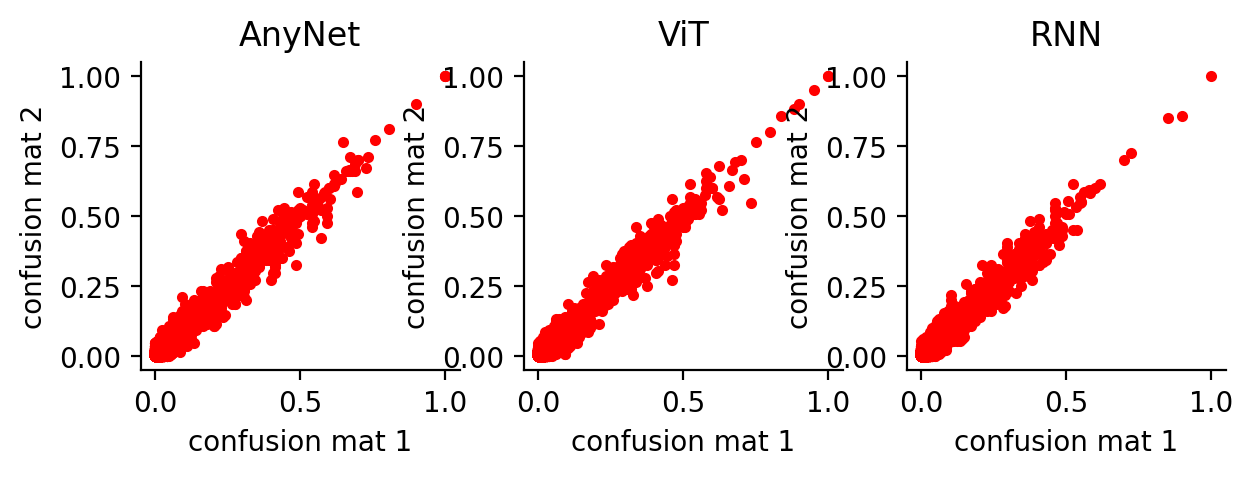

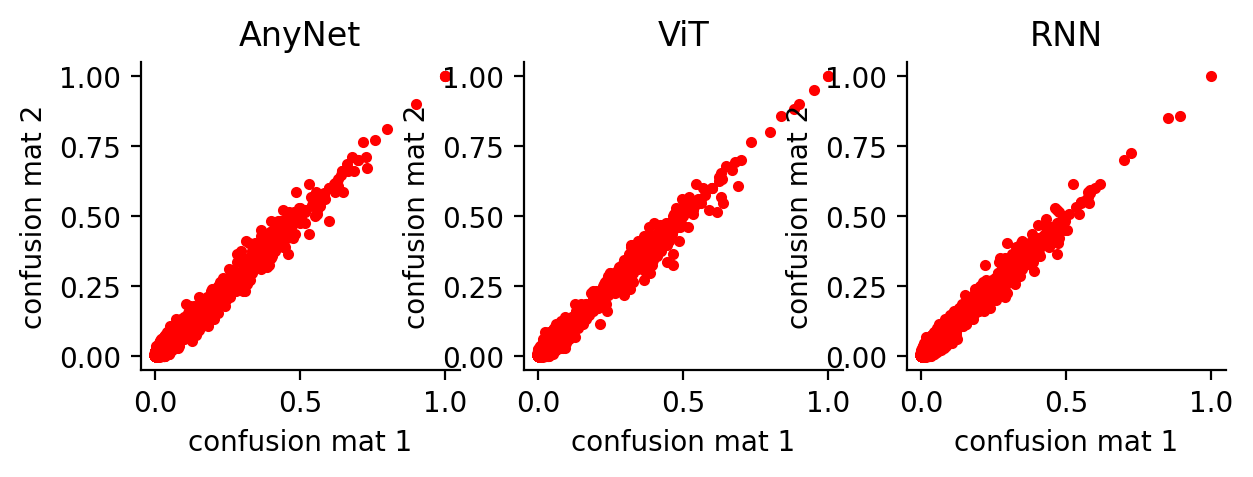

In [ ]:
plt.figure(figsize=(7, 2), dpi=200)
for ii, classifier_name in enumerate(['AnyNet', 'ViT', 'RNN']):
    plt.subplot(1, 3, ii + 1)
    plt.plot(Mat_dict_rest_repeat[0][classifier_name], Mat_dict_rest[classifier_name], 'r.')
    plt.title(classifier_name)
    plt.xlabel('confusion mat 1')
    plt.ylabel('confusion mat 2')


sns.despine()
plt.show()

plt.figure(figsize=(7, 2), dpi=200)
for ii, classifier_name in enumerate(['AnyNet', 'ViT', 'RNN']):
    plt.subplot(1, 3, ii + 1)
    plt.plot(Mat_dict_rest_512_repeat[0][classifier_name], Mat_dict_rest[classifier_name], 'r.')
    plt.title(classifier_name)
    plt.xlabel('confusion mat 1')
    plt.ylabel('confusion mat 2')


sns.despine()
plt.show()

In [ ]:
pos

array([14])

In [ ]:
pos

array([], dtype=int64)

In [ ]:
community_dict_rest[1.0]['communities_label'][np.argwhere(community_dict_rest[1.0]['communities_acronym'] == 'LP').flatten()]



array([19])

In [ ]:
for label_ind, _ in enumerate(community_dict_rest[1.0]['communities_label']):
    print(f"brain area: {community_dict_rest[1.0]['communities_acronym'][label_ind]}, community index: {community_dict_rest[1.0]['communities_label'][label_ind]}")


brain area: KF, community index: 0
brain area: I5, community index: 0
brain area: DCO, community index: 0
brain area: VCO, community index: 0
brain area: CU, community index: 0
brain area: ECU, community index: 0
brain area: SPVC, community index: 0
brain area: SPVI, community index: 0
brain area: Pa5, community index: 0
brain area: AMBv, community index: 0
brain area: GRN, community index: 0
brain area: ICB, community index: 0
brain area: IO, community index: 0
brain area: IRN, community index: 0
brain area: LIN, community index: 0
brain area: LRNm, community index: 0
brain area: MARN, community index: 0
brain area: MDRNd, community index: 0
brain area: MDRNv, community index: 0
brain area: PARN, community index: 0
brain area: PAS, community index: 0
brain area: PGRNd, community index: 0
brain area: PGRNl, community index: 0
brain area: PRP, community index: 0
brain area: LAV, community index: 0
brain area: MV, community index: 0
brain area: SPIV, community index: 0
brain area: x, com

In [15]:
resolution = 1.0
for rep in range(0, 1):

    community_number = []
    community_index = {}
    for name in ['AnyNet', 'ViT', 'RNN']:

        X = copy.deepcopy(Mat_dict_rest_1024_repeat[rep][name])
        community_label, acronym_label, index = modularity_separation(X, resolution)

        community_number.append(len(np.unique(community_label)))
        community_index[name] = community_label

    communities = []
    communities_label = []
    communities_acronym = []
    ii = 0
    for community_ii_AnyNet in range(0, community_number[0]):
        for community_ii_ViT in range(0, community_number[1]):
            for community_ii_RNN in range(0, community_number[2]):
                community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                if len(community0) > 2:
                    communities.append(community0)
                    communities_acronym.append(np.array(acronym_list)[community0])
                    communities_label.append(ii * np.ones_like(community0))
                    ii = ii + 1

    communities = np.concat(communities)
    communities_label = np.concat(communities_label)
    communities_acronym = np.concat(communities_acronym)


community_dict = {}

community_dict['communities'] = communities
community_dict['communities_label'] = communities_label
community_dict['communities_acronym'] = communities_acronym



In [ ]:
resolution = 1.0

ratio_dict = {}
ratio_list = []
label_list = []

for label_id in np.unique(community_dict['communities_label']):
    br_center = community_dict['communities_acronym'][np.argwhere(community_dict['communities_label'] == label_id).flatten()[0]]
    overlap_ratio = []
    for rep in range(0, 10):
        try:

            label_selec = community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == br_center).flatten()]
            acronym_selec = community_dict['communities_acronym'][np.argwhere(community_dict['communities_label'] == label_selec).flatten()]
            acronym_id_selec = community_dict['communities'][np.argwhere(community_dict['communities_label'] == label_selec).flatten()]

            community_number = []
            community_index = {}
            community_dat_ho = {}
            for name in ['AnyNet', 'ViT', 'RNN']:

                X = copy.deepcopy(Mat_dict_rest_1024_repeat[rep][name])
                community_label, acronym_label, index = modularity_separation(X, resolution)

                community_number.append(len(np.unique(community_label)))
                community_index[name] = community_label

            communities = []
            communities_label = []
            communities_acronym = []
            ii = 0
            for community_ii_AnyNet in range(0, community_number[0]):
                for community_ii_ViT in range(0, community_number[1]):
                    for community_ii_RNN in range(0, community_number[2]):
                        community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                        np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                        np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                        if len(community0) > 2:
                            communities.append(community0)
                            communities_acronym.append(np.array(acronym_list)[community0])
                            communities_label.append(ii * np.ones_like(community0))
                            ii = ii + 1

            communities = np.concat(communities)
            communities_label = np.concat(communities_label)
            communities_acronym = np.concat(communities_acronym)

            community_dat_ho['communities'] = communities
            community_dat_ho['communities_label'] = communities_label
            community_dat_ho['communities_acronym'] = communities_acronym

            label_selec_ho = community_dat_ho['communities_label'][np.argwhere(community_dat_ho['communities_acronym'] == br_center).flatten()]
            acronym_selec_ho = community_dat_ho['communities_acronym'][np.argwhere(community_dat_ho['communities_label'] == label_selec_ho).flatten()]

        except:
            continue

        overlap_ratio.append(len(np.intersect1d(acronym_selec_ho, acronym_selec)) / len(acronym_selec))

    overlap_ratio = np.array(overlap_ratio)
    ratio_list.append(overlap_ratio.mean())
    label_list.append(label_id)
    print(label_id)

ratio_dict['ratio'] = np.array(ratio_list)
ratio_dict['label_id'] = np.array(label_list)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27


In [ ]:
# torch.save(ratio_dict, '/content/drive/MyDrive/Project/BrainRegionId/Nature/results/communities/ratio_dict_stimOff_times.pt')

In [ ]:
# from google.colab import runtime
# runtime.unassign()